In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [3]:
"""
numeric data (linear)
"""

'\nnumeric data (linear)\n'

In [4]:
# Generate Linear Data
np.random.seed(42)
n = 1000

# --- MCAR ---

# 1000 evenly spaced numbers from 0 to 100
x = np.linspace(0, 100, n)
# y = 2x + 5 + noise
y = 2 * x + 5 + np.random.normal(0, 10, n)
df1 = pd.DataFrame({'Feature_A': x, 'Feature_B': y})

# Punch holes (20% missing)
perc_missing = round(n  * 0.2)
df_miss_MCAR = df1.copy()
df_miss_MCAR.iloc[np.random.choice(n, perc_missing , replace=False), 1] = np.nan

missing_values_df_MCAR = missing_values_table(df_miss_MCAR)
missing_values_df_MCAR

Your selected dataframe has 2 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Feature_B,200,20.0


In [5]:
# --- MAR ---

# Generate observed variable
age = np.random.normal(40, 10, n)
# Generate target variable
income = 30000 + age * 1000 + np.random.normal(0, 5000, n)
df2 = pd.DataFrame({"Feature_A": age, "Feature_B": income})

# Create MAR missingness in Income depending on Age
prob_missing = 1 / (1 + np.exp(-(age - 50) / 5))
missing_mask = np.random.rand(n) < prob_missing
df_miss_MAR = df2.copy()
df_miss_MAR.loc[missing_mask, "Feature_B"] = np.nan

missing_values_df_MAR = missing_values_table(df_miss_MAR)
missing_values_df_MAR

Your selected dataframe has 2 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Feature_B,255,25.5


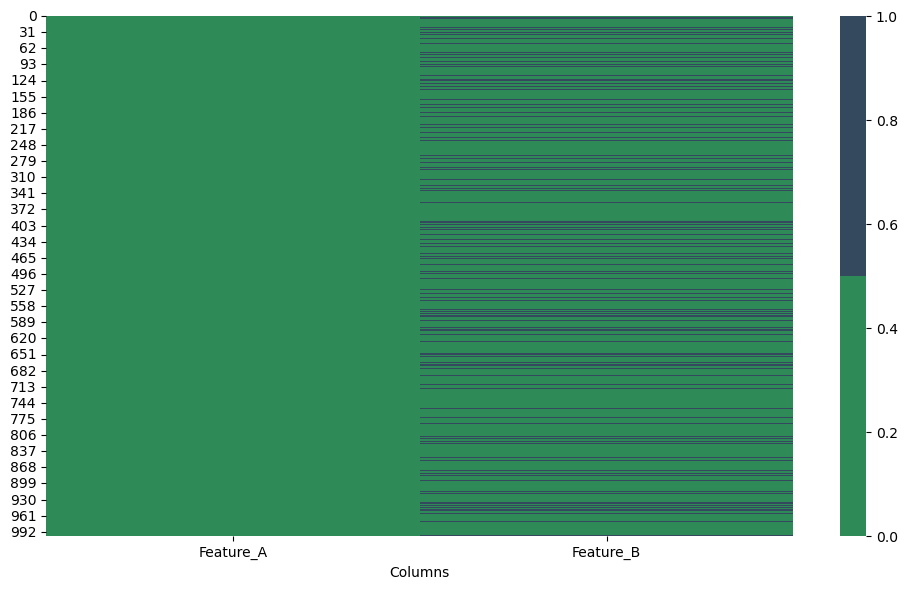

In [6]:
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
sns.heatmap(df_miss_MCAR.isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

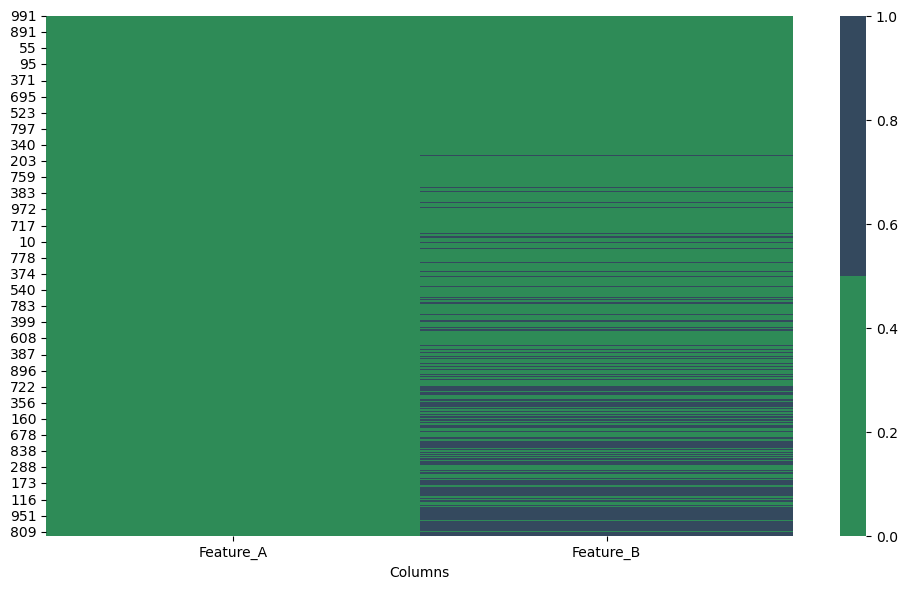

In [7]:
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
df_miss_MAR = df_miss_MAR.sort_values("Feature_A")
# in order to understand the MAR, it has to be in sorted order of a column that we suspect has impact on missing value
# if we do similarly to the MCAR, the missing values are still seen scattered
sns.heatmap(df_miss_MAR.isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

<Axes: >

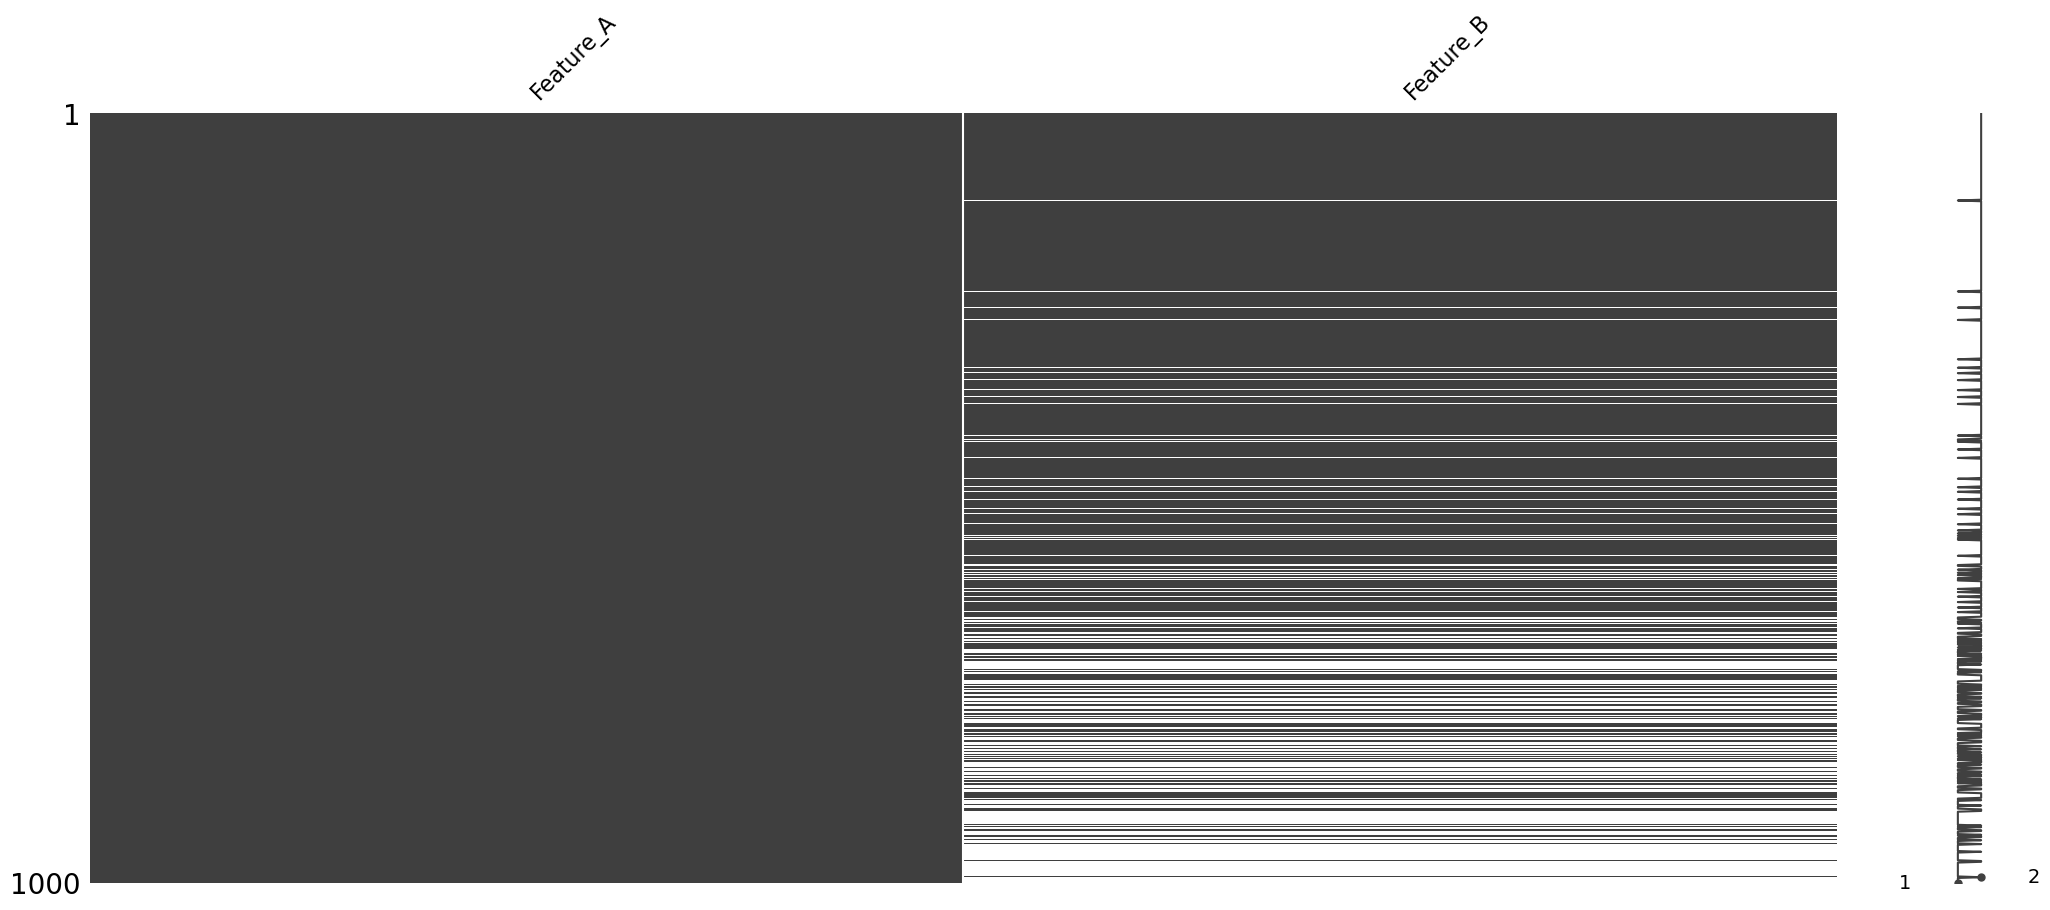

In [8]:
# missingno library produces the same results
df_miss_MAR = df_miss_MAR.sort_values("Feature_A")
msno.matrix(df_miss_MAR)

<Axes: >

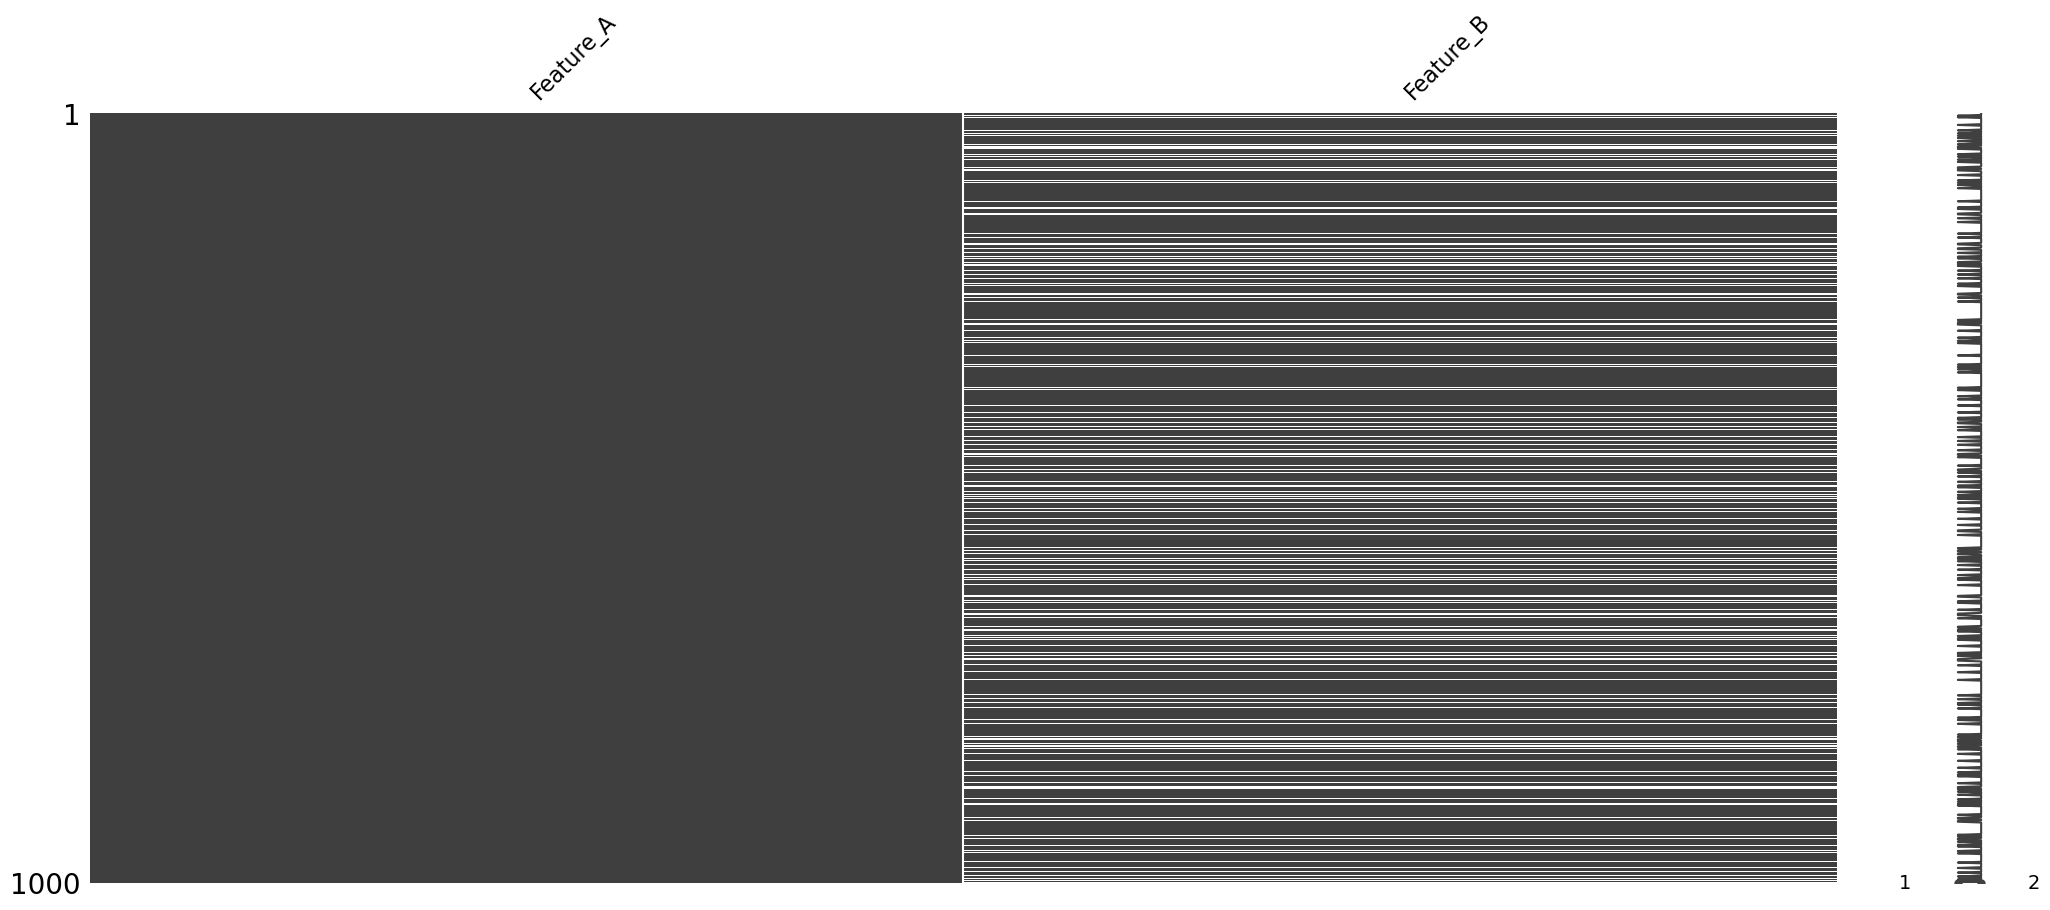

In [9]:
msno.matrix(df_miss_MCAR)

<Axes: >

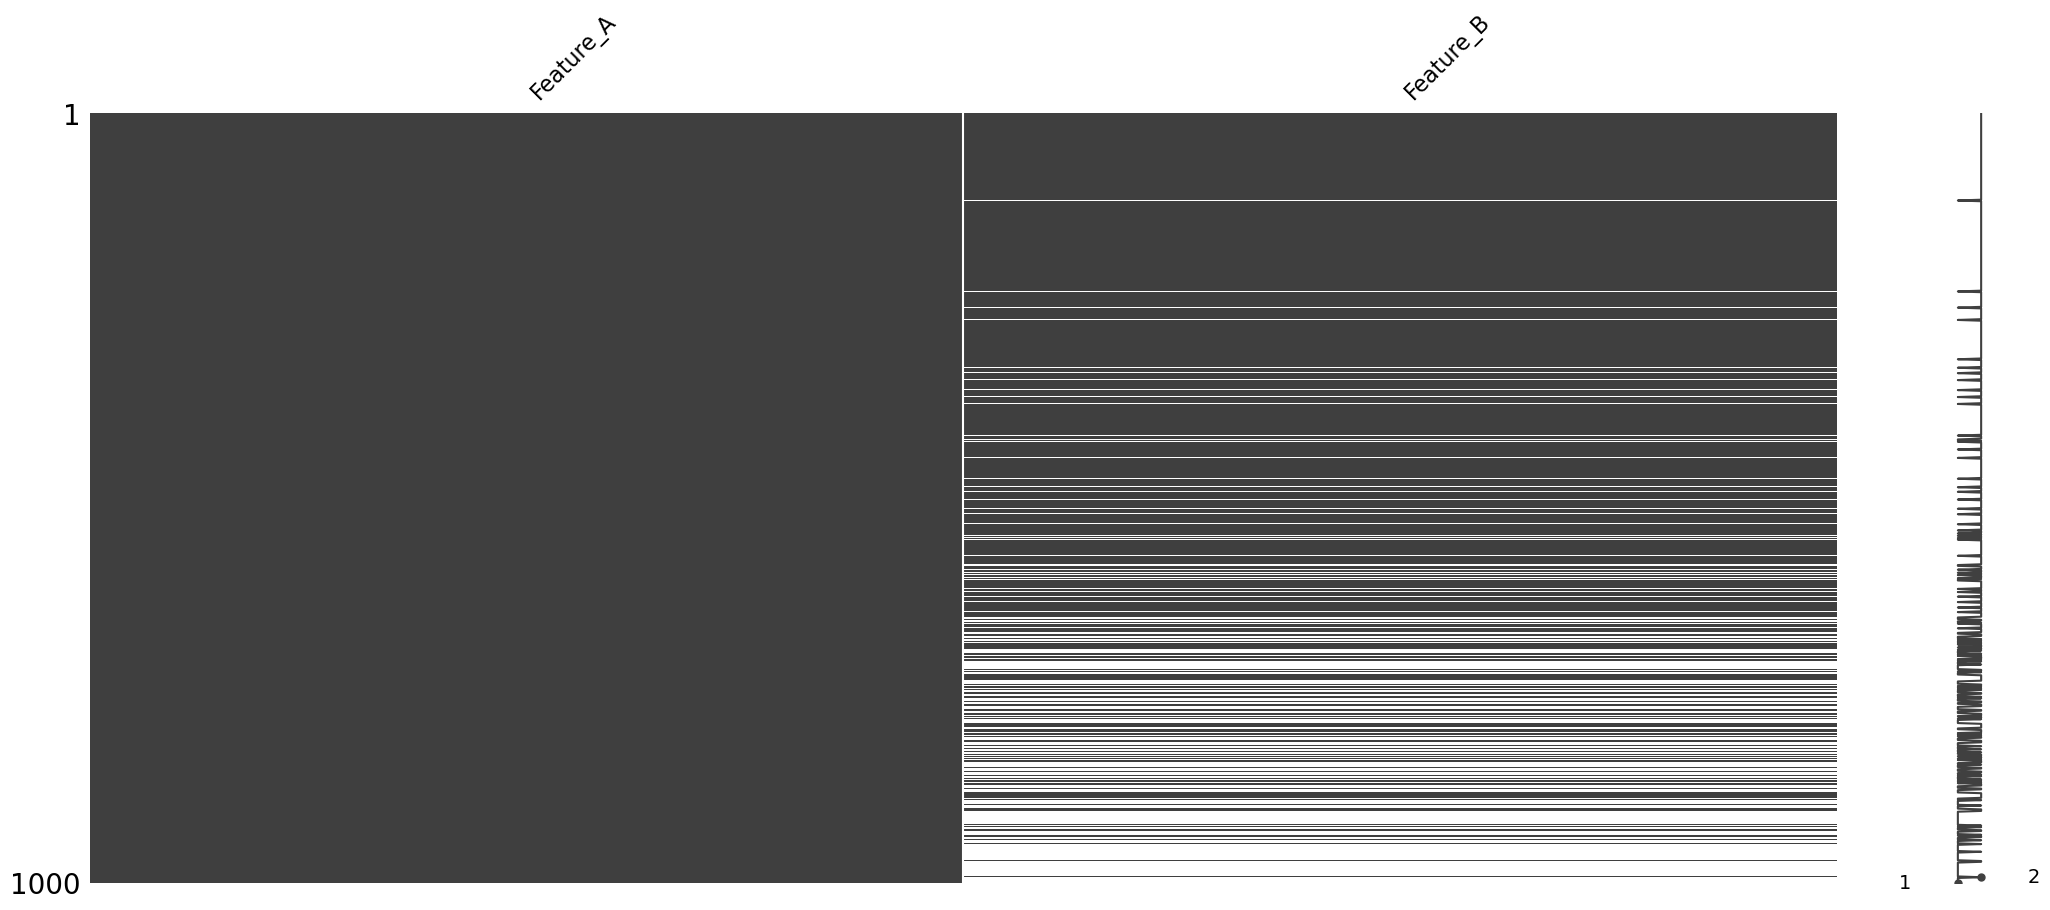

In [10]:
msno.matrix(df_miss_MAR)

In [41]:
np.random.seed(42)
n = 1000

age        = np.random.normal(40, 10, n)
experience = np.clip(age - 22 + np.random.normal(0, 3, n), 0, 40)
income     = 30000 + age * 1000 + experience * 500 + np.random.normal(0, 5000, n)
savings    = income * 0.2 + np.random.normal(0, 3000, n)
debt       = np.random.normal(15000, 5000, n)

df = pd.DataFrame({
    'Age':        age,
    'Experience': experience,
    'Income':     income,
    'Savings':    savings,
    'Debt':       debt
})

# --- MCAR — Income: purely random, independent ---
mcar_idx = np.random.choice(n, round(n * 0.2), replace=False)
df.iloc[mcar_idx, df.columns.get_loc('Income')] = np.nan

# --- MAR group — Income AND Savings AND Experience missing TOGETHER ---
# when Age > 50, all three go missing at the same rows
# msno.heatmap will show HIGH correlation between these three
age_over_50      = age > 50
group_candidates = np.where(age_over_50)[0]
group_idx        = np.random.choice(
                        group_candidates,
                        round(len(group_candidates) * 0.5),
                        replace=False
                   )
df.iloc[group_idx, df.columns.get_loc('Savings')]    = np.nan
df.iloc[group_idx, df.columns.get_loc('Experience')] = np.nan
df.iloc[group_idx, df.columns.get_loc('Debt')]       = np.nan

print("Missing per column:")
print(df.isnull().mean().round(3))

Missing per column:
Age           0.000
Experience    0.078
Income        0.200
Savings       0.078
Debt          0.078
dtype: float64


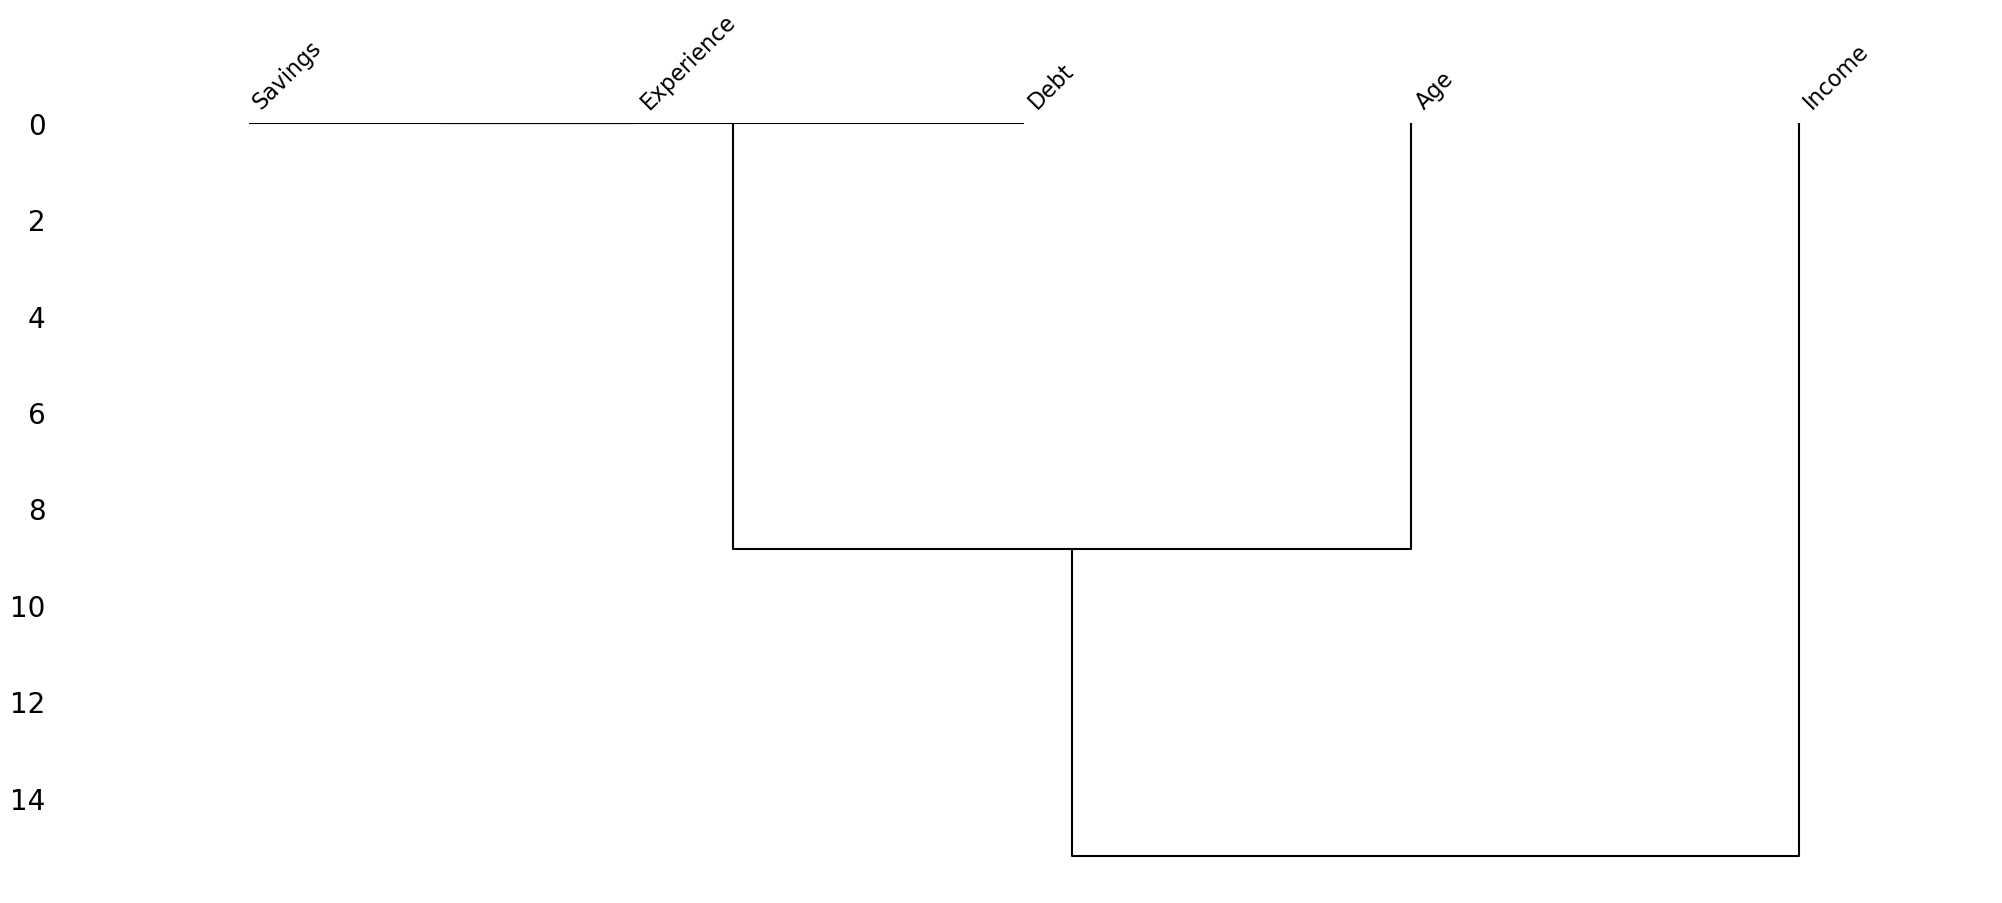

In [42]:
# columns which have missing value together cluster together
msno.dendrogram(df);

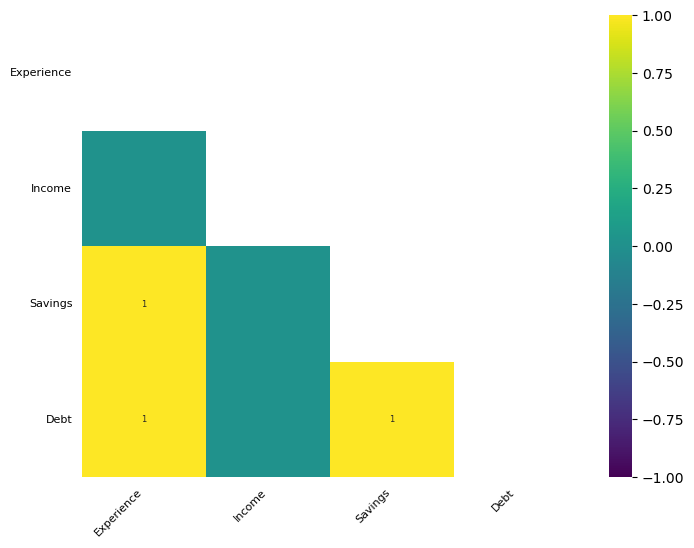

In [43]:
# correlation of missingness bw columns
msno.heatmap(df, figsize=(8,6), cmap="viridis", fontsize=8);

In [ ]:
"""
High correlation (r > 0.3)  →  Experience, Savings, Debt  →  MAR group 
low  correlation (r ≈ 0.0)  →  Income                     →  MCAR 
"""